In [73]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

### Get File path and load the csv data

In [74]:
from util.data_path import cassava_price_avg as data_file

In [75]:
wide = pd.read_csv(data_file)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

### Set the training dataset and the predicted data

In [76]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

In [77]:
y_train = train["price"].asfreq("MS")
y_test = future["price"].asfreq("MS")

SEQ_LEN = 12
PRED_LEN = 12

### Predict the data for the next year

In [78]:
sf_data = (
    y_train.rename("y")
    .to_frame()
    .assign(ds=lambda df: df.index, unique_id="cassava")
    .reset_index(drop=True)
)

sf = StatsForecast(
    models=[
        AutoARIMA(
            season_length=12,  # monthly
            approximation=False,
        )
    ],
    freq="MS",  # month start
)

### Compare The Error of a predicted data and the actual data in a table format

In [79]:
sf_forecasts = sf.fit_predict(df=sf_data, h=12)
arima_sf = sf_forecasts.set_index("ds")["AutoARIMA"]


error = y_test - arima_sf
abs_error = abs(error)

mae_arima = mean_absolute_error(y_test, arima_sf)
error = pd.DataFrame(
    {
        "actual": y_test,
        "arima_sf": arima_sf,
        "mae_arima": abs_error,
    }
)


In [80]:
cmp = pd.concat([future["price"], arima_sf], axis=1)
print("\n--- Actual vs Forecast (debug view) ---")
print(cmp.round(2))

print(f"MAE ARIMA: {mae_arima:.3f}")
print(f"ARIMA Accuracy = {100 - (mae_arima / y_test.mean() * 100):.2f}%")


--- Actual vs Forecast (debug view) ---
            price  AutoARIMA
2024-01-01   3.65       3.65
2024-02-01   3.65       3.64
2024-03-01   3.57       3.64
2024-04-01   3.24       3.64
2024-05-01   3.19       3.64
2024-06-01   3.09       3.64
2024-07-01   3.06       3.64
2024-08-01   2.95       3.64
2024-09-01   2.86       3.64
2024-10-01   2.65       3.64
2024-11-01   2.60       3.64
2024-12-01   2.32       3.64
MAE ARIMA: 0.577
ARIMA Accuracy = 81.21%


In [81]:
forecast_dir = Path("forecast_price")
forecast_dir = forecast_dir / "ARIMA"
forecast_dir.mkdir(exist_ok=True)

import os  # Add missing import

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"{data_file.parent.name}_forecast.txt"
filepath = forecast_dir / filename

# Save forecast data to text file
with open(filepath, "w") as f:
    f.write(f"LSTM Forecast Results for Soybean Prices (2024) {timestamp}\n")
    f.write("=" * 50 + "\n\n")
    f.write("Forecast Data:\n")
    f.write("-" * 20 + "\n")
    for date, price in arima_sf.items():
        f.write(f"{date.strftime('%Y-%m-%d')}: {price:.2f}\n")

    f.write("\nOverall Statistics:\n")
    f.write("-" * 20 + "\n")
    f.write(f"Mean Arima_sf Price: {arima_sf.mean():.2f}\n")
    f.write(f"Min Arima_sf Price: {arima_sf.min():.2f}\n")
    f.write(f"Max Arima_sf Price: {arima_sf.max():.2f}\n")
    f.write(f"Standard Deviation: {arima_sf.std():.2f}\n")

print(f"Forecast prices saved to: {filepath}")
print(f"File size: {os.path.getsize(filepath)} bytes")

Forecast prices saved to: forecast_price\ARIMA\cassava_forecast.txt
File size: 523 bytes


### Plot The predicted data compare to an actual data

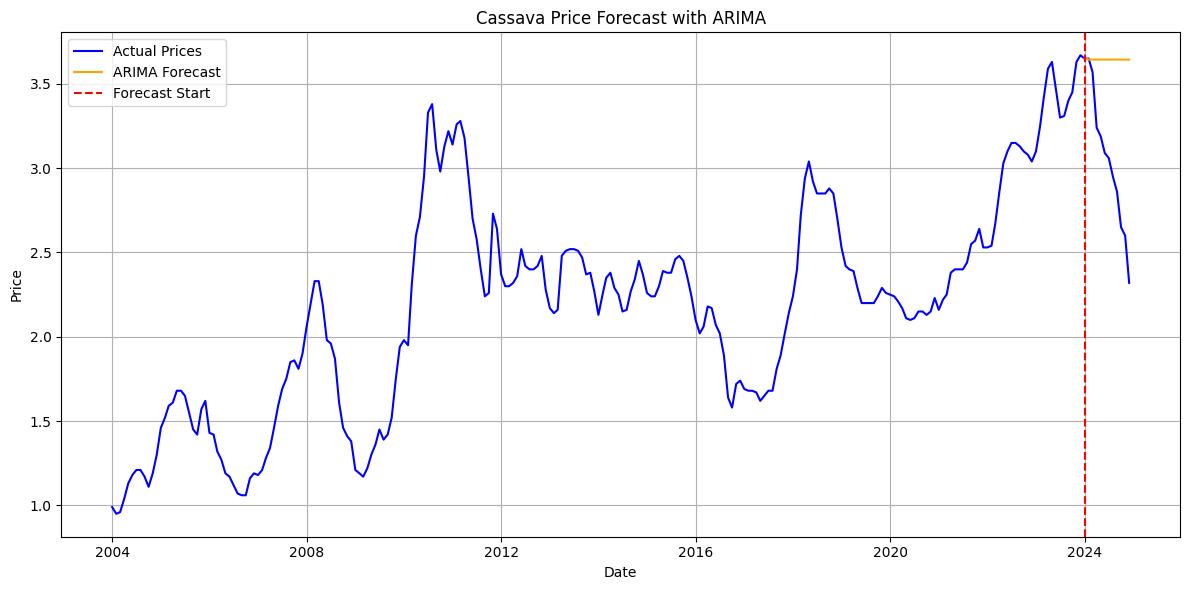

In [82]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(arima_sf.index, arima_sf, label="ARIMA Forecast", color="orange")
plt.axvline(
    x=pd.Timestamp(f"{gregorian_2567}-01-01"),
    color="red",
    linestyle="--",
    label="Forecast Start",
)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Cassava Price Forecast with ARIMA")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

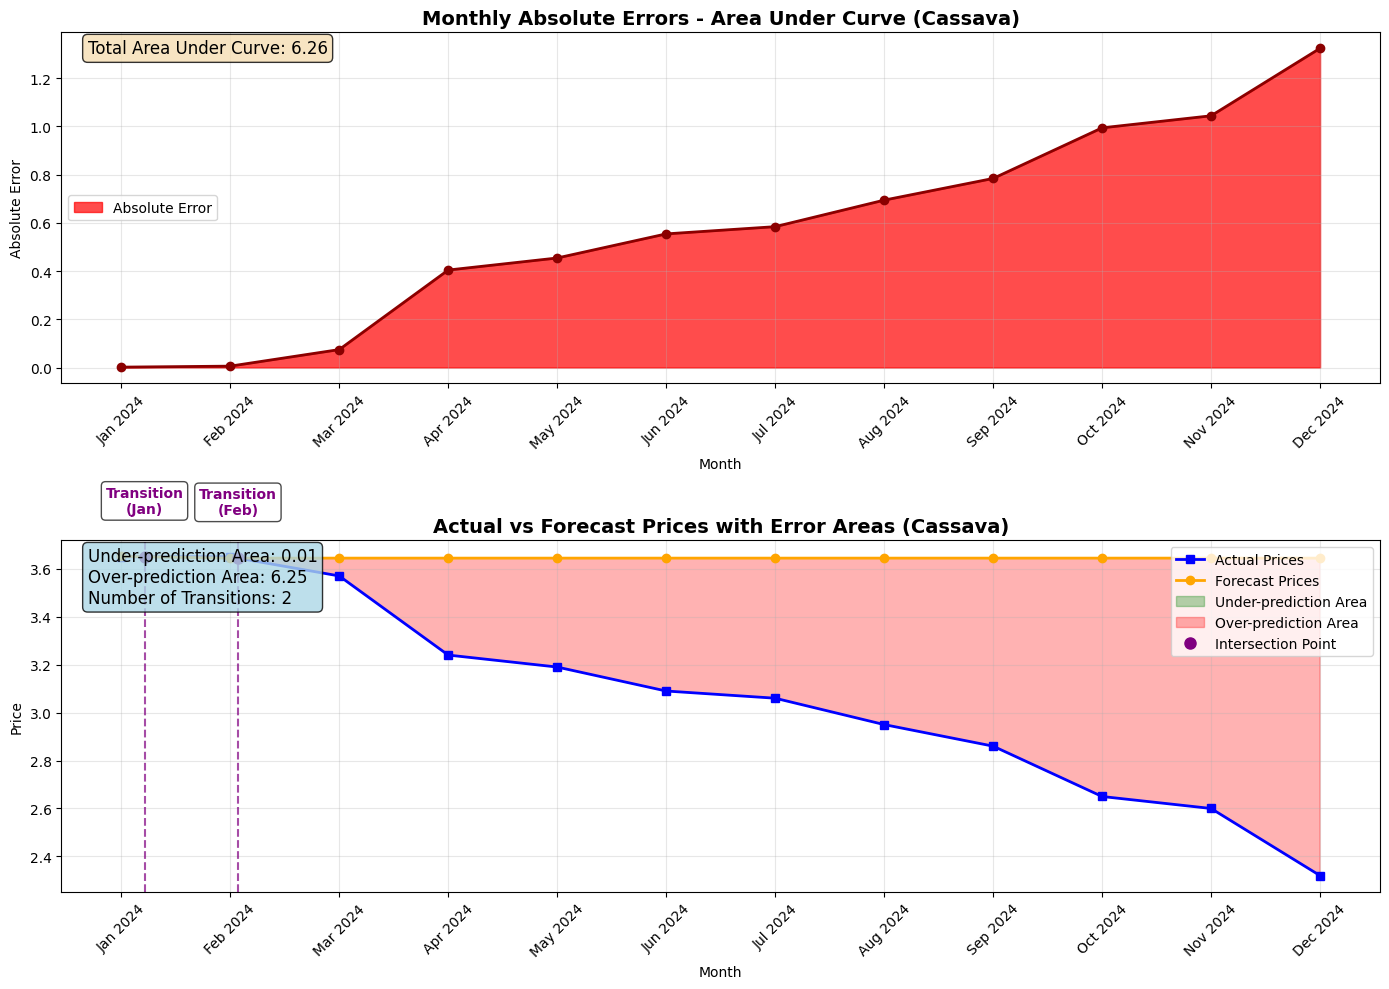

In [83]:
# Create area plot to visualize monthly errors
plt.figure(figsize=(14, 8))

# Calculate error values (in case this cell is run before the error calculation cell)
error = cmp["price"] - cmp["AutoARIMA"]
abs_error = abs(error)

# Add the error columns to the cmp DataFrame if they don't exist
if "error" not in cmp.columns:
    cmp["error"] = error
if "abs_error" not in cmp.columns:
    cmp["abs_error"] = abs_error

# Create month labels for better readability
month_labels = [date.strftime("%b %Y") for date in cmp.index]

# Create subplots for different error visualizations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Area plot of absolute errors
ax1.fill_between(
    range(len(cmp)), cmp["abs_error"], alpha=0.7, color="red", label="Absolute Error"
)
ax1.plot(range(len(cmp)), cmp["abs_error"], color="darkred", linewidth=2, marker="o")
ax1.set_title(
    f"Monthly Absolute Errors - Area Under Curve ({data_file.parent.name.capitalize()})",
    fontsize=14,
    fontweight="bold",
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Absolute Error")
ax1.set_xticks(range(len(cmp)))
ax1.set_xticklabels(month_labels, rotation=45)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add area calculation text
total_area = np.trapezoid(cmp["abs_error"])
ax1.text(
    0.02,
    0.98,
    f"Total Area Under Curve: {total_area:.2f}",
    transform=ax1.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Plot 2: Comparison of actual vs forecast with error areas
ax2.plot(
    range(len(cmp)),
    cmp["price"],
    label="Actual Prices",
    color="blue",
    linewidth=2,
    marker="s",
)
ax2.plot(
    range(len(cmp)),
    cmp["AutoARIMA"],
    label="Forecast Prices",
    color="orange",
    linewidth=2,
    marker="o",
)

# Find intersection points between actual and forecast
intersect_indices = []
for i in range(1, len(cmp)):
    # Check if actual and forecast cross between i-1 and i
    prev_diff = cmp["price"].iloc[i - 1] - cmp["AutoARIMA"].iloc[i - 1]
    curr_diff = cmp["price"].iloc[i] - cmp["AutoARIMA"].iloc[i]

    if (prev_diff * curr_diff <= 0) and (
        prev_diff != 0 or curr_diff != 0
    ):  # Sign change or one is zero
        # Linear interpolation to find exact intersection point
        if prev_diff == curr_diff:  # They're equal (both 0)
            t = 0  # At point i-1
        else:
            t = abs(prev_diff) / (abs(prev_diff) + abs(curr_diff))

        intersect_x = (i - 1) + t
        intersect_y = cmp["price"].iloc[i - 1] + t * (
            cmp["price"].iloc[i] - cmp["price"].iloc[i - 1]
        )

        intersect_indices.append((intersect_x, intersect_y))

# Fill areas between actual and forecast to show errors
ax2.fill_between(
    range(len(cmp)),
    cmp["price"],
    cmp["AutoARIMA"],
    where=(cmp["price"] >= cmp["AutoARIMA"]),
    color="green",
    alpha=0.3,
    label="Under-prediction Area",
    interpolate=True,
)
ax2.fill_between(
    range(len(cmp)),
    cmp["price"],
    cmp["AutoARIMA"],
    where=(cmp["price"] < cmp["AutoARIMA"]),
    color="red",
    alpha=0.3,
    label="Over-prediction Area",
    interpolate=True,
)

# Mark intersection points with vertical lines and markers
for idx, (x, y) in enumerate(intersect_indices):
    ax2.axvline(x, color="purple", linestyle="--", alpha=0.7, linewidth=1.5)
    ax2.plot(
        x,
        y,
        "o",
        color="purple",
        markersize=8,
        label="Intersection Point" if idx == 0 else "",
    )
    ax2.text(
        x,
        y * 1.05,
        f"Transition\n({month_labels[int(x)][:3]})",
        ha="center",
        color="purple",
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.3"),
    )

ax2.set_title(
    f"Actual vs Forecast Prices with Error Areas ({data_file.parent.name.capitalize()})",
    fontsize=14,
    fontweight="bold",
)
ax2.set_xlabel("Month")
ax2.set_ylabel("Price")
ax2.set_xticks(range(len(cmp)))
ax2.set_xticklabels(month_labels, rotation=45)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

# Calculate and display area statistics
under_pred_area = np.trapezoid(np.maximum(cmp["price"] - cmp["AutoARIMA"], 0))
over_pred_area = np.trapezoid(np.maximum(cmp["AutoARIMA"] - cmp["price"], 0))

# Count number of transitions
num_transitions = len(intersect_indices)

# Create statistics text
stats_text = (
    f"Under-prediction Area: {under_pred_area:.2f}\n"
    f"Over-prediction Area: {over_pred_area:.2f}\n"
    f"Number of Transitions: {num_transitions}"
)

ax2.text(
    0.02,
    0.98,
    stats_text,
    transform=ax2.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8),
)

plt.tight_layout()
plt.show()